# Exploratory analysis of San Diego traffic flow

This notebook focuses on the checks that matter before building a forecasting model: data quality, flow ranges, sensor-level behavior, direction-level averages, seasonal patterns, and temporal dependence.

Each history column is a sensor and each row is one timestamp. A reading represents traffic flow during that interval; it is not a cumulative counter.

## 1. Load the data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
metadata = pd.read_csv(DATA_DIR / "sd_meta.csv")
traffic = pd.read_hdf(DATA_DIR / "sd_his_2019.h5")

# Use strings for sensor IDs so history columns match metadata IDs reliably.
traffic.columns = traffic.columns.astype(str)
metadata["ID"] = metadata["ID"].astype(str)

print(f"Traffic: {traffic.shape[0]:,} timestamps × {traffic.shape[1]:,} sensors")
print(f"Metadata: {metadata.shape[0]:,} sensors × {metadata.shape[1]:,} columns")
print(f"Traffic memory: {traffic.memory_usage(deep=True).sum() / 1024**2:,.1f} MiB")

Traffic: 105,120 timestamps × 716 sensors
Metadata: 716 sensors × 10 columns
Traffic memory: 575.0 MiB


In [2]:
display(metadata.head())
display(traffic.iloc[:5, :10])

print("Date range:", traffic.index.min(), "to", traffic.index.max())
print("Index type:", type(traffic.index).__name__)
print("Duplicate timestamps:", int(traffic.index.duplicated().sum()))
print("Sorted timestamps:", traffic.index.is_monotonic_increasing)
if isinstance(traffic.index, pd.DatetimeIndex):
    print("Inferred frequency:", pd.infer_freq(traffic.index[: min(10_000, len(traffic))]))
print("History dtypes:")
display(traffic.dtypes.value_counts().rename("columns").to_frame())

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935


,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450
Time,,,,,,,,,,
2019-01-01 00:00:00,33.0,19.0,20.0,14.0,12.0,37.0,38.0,46.0,64.0,56.0
2019-01-01 00:05:00,35.0,26.0,25.0,20.0,22.0,56.0,23.0,28.0,45.0,47.0
2019-01-01 00:10:00,18.0,24.0,26.0,44.0,31.0,75.0,45.0,57.0,57.0,54.0
2019-01-01 00:15:00,36.0,20.0,23.0,35.0,26.0,94.0,89.0,85.0,99.0,96.0
2019-01-01 00:20:00,24.0,21.0,15.0,31.0,37.0,107.0,103.0,103.0,96.0,102.0


Date range: 2019-01-01 00:00:00 to 2019-12-31 23:55:00
Index type: DatetimeIndex
Duplicate timestamps: 0
Sorted timestamps: True
Inferred frequency: 5min
History dtypes:


,columns
float64,716


## 2. Metadata overview

These are the static properties available for each sensor.

In [3]:
metadata_overview = pd.DataFrame({
    "dtype": metadata.dtypes.astype(str),
    "missing": metadata.isna().sum(),
    "unique": metadata.nunique(dropna=True),
})
display(metadata_overview)

for column in ["District", "County", "Fwy", "Lanes", "Type", "Direction"]:
    print(f"\n{column}")
    display(metadata[column].value_counts(dropna=False).rename("sensors").to_frame())

,dtype,missing,unique
ID,str,0,716
Lat,float64,0,716
Lng,float64,0,714
District,int64,0,1
County,str,0,1
Fwy,str,0,26
Lanes,int64,0,7
Type,str,0,1
Direction,str,0,4
ID2,int64,0,716



District


,sensors
District,
11,716



County


,sensors
County,
San Diego,716


...

,sensors
Lanes,
4,315
5,139
3,134
2,73
6,48
7,5
8,2



Type


,sensors
Type,
Mainline,716



Direction


,sensors
Direction,
N,242
S,221
W,137
E,116


## 3. Missing values, ranges, averages, and unique values

The summary below is calculated for every sensor. Zero and `999` rates are shown separately because either boundary can deserve investigation. In some prepared PeMS datasets, missing observations are represented by zero, so do not automatically interpret every zero as genuine zero traffic.

In [4]:
sensor_summary = traffic.describe().T
sensor_summary.index.name = "sensor_id"
sensor_summary["missing"] = traffic.isna().sum()
sensor_summary["missing_%"] = traffic.isna().mean().mul(100)
sensor_summary["unique_values"] = traffic.nunique(dropna=True)
sensor_summary["zero_%"] = traffic.eq(0).mean().mul(100)
sensor_summary["value_999_%"] = traffic.eq(999).mean().mul(100)
sensor_summary["range"] = sensor_summary["max"] - sensor_summary["min"]

summary_columns = [
    "count", "missing", "missing_%", "zero_%", "value_999_%",
    "min", "max", "mean", "50%", "std", "range", "unique_values",
]
display(sensor_summary[summary_columns])

,count,missing,missing_%,zero_%,value_999_%,min,max,mean,50%,std,range,unique_values
sensor_id,,,,,,,,,,,,
1114091,105120.0,0,0.0,0.021880,0.0,0.0,364.0,178.287139,180.0,53.973180,364.0,326
1118333,105120.0,0,0.0,0.022831,0.0,0.0,170.0,75.923506,76.0,23.799596,170.0,161
1118348,105120.0,0,0.0,0.020928,0.0,0.0,207.0,87.695776,94.0,29.524331,207.0,180
1114720,105120.0,0,0.0,0.022831,0.0,0.0,320.0,131.784256,147.0,50.644719,320.0,255
1118352,105120.0,0,0.0,0.019977,0.0,0.0,305.0,132.547108,149.0,54.266690,305.0,274
...,...,...,...,...,...,...,...,...,...,...,...,...
1123276,105120.0,0,0.0,0.021880,0.0,0.0,337.0,119.270148,118.0,50.942804,337.0,311
1122394,105120.0,0,0.0,0.027588,0.0,0.0,310.0,87.674229,90.0,43.508068,310.0,246
1123261,105120.0,0,0.0,0.024734,0.0,0.0,362.0,74.248887,78.0,34.920703,362.0,331


In [5]:
total_values = traffic.size
total_missing = int(sensor_summary["missing"].sum())
total_zeros = int(traffic.eq(0).sum().sum())
total_999 = int(traffic.eq(999).sum().sum())

overall_average = np.average(sensor_summary["mean"], weights=sensor_summary["count"])
print(f"Overall range: {sensor_summary['min'].min():,.0f} to {sensor_summary['max'].max():,.0f}")
print(f"Overall average: {overall_average:,.2f}")
print(f"Missing: {total_missing:,} ({100 * total_missing / total_values:.3f}%)")
print(f"Zeros: {total_zeros:,} ({100 * total_zeros / total_values:.3f}%)")
print(f"Values equal to 999: {total_999:,} ({100 * total_999 / total_values:.5f}%)")

# Representative unique values from evenly sampled timestamps.
sample_positions = np.linspace(0, len(traffic) - 1, min(10_000, len(traffic)), dtype=int)
sampled_values = traffic.iloc[sample_positions].to_numpy().ravel()
sampled_values = sampled_values[~pd.isna(sampled_values)]
sampled_unique = np.unique(sampled_values)
print(f"Unique values in the time sample: {len(sampled_unique):,}")
print("Lowest unique values:", sampled_unique[:20])
print("Highest unique values:", sampled_unique[-20:])

Overall range: 0 to 999
Overall average: 244.22
Missing: 0 (0.000%)
Zeros: 1,750,565 (2.326%)
Values equal to 999: 207 (0.00028%)
Unique values in the time sample: 1,000
Lowest unique values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
Highest unique values: [980. 981. 982. 983. 984. 985. 986. 987. 988. 989. 990. 991. 992. 993.
 994. 995. 996. 997. 998. 999.]


## 4. Average flow per sensor and direction

In [6]:
metadata_by_id = metadata.set_index("ID")
sensor_analysis = sensor_summary.join(
    metadata_by_id[["Fwy", "Direction", "Lanes", "Lat", "Lng"]],
    how="left",
)

print("Sensors with the highest average flow")
display(sensor_analysis.sort_values("mean", ascending=False)[
    ["Fwy", "Direction", "Lanes", "mean", "50%", "min", "max", "missing_%", "zero_%"]
].head(20))

direction_summary = sensor_analysis.groupby("Direction").agg(
    sensors=("mean", "size"),
    average_flow=("mean", "mean"),
    median_sensor_flow=("mean", "median"),
    minimum_sensor_average=("mean", "min"),
    maximum_sensor_average=("mean", "max"),
    average_lanes=("Lanes", "mean"),
).sort_values("average_flow", ascending=False)

print("Average flow by direction (each sensor weighted equally)")
display(direction_summary.round(2))

Sensors with the highest average flow


,Fwy,Direction,Lanes,mean,50%,min,max,missing_%,zero_%
sensor_id,,,,,,,,,
1120611,I15-N,N,8,518.150514,569.0,0.0,999.0,0.0,1.522070
1115838,I15-S,S,6,487.801475,559.0,0.0,999.0,0.0,0.668760
1122469,I15-N,N,7,484.211958,533.0,0.0,930.0,0.0,0.021880
1115739,I15-N,N,6,483.306231,533.0,0.0,999.0,0.0,0.058980
1122479,I15-S,S,7,466.113680,512.0,0.0,999.0,0.0,3.789003
1123031,I15-N,N,6,464.466714,532.0,0.0,999.0,0.0,0.056126
1115749,I15-N,N,6,461.095158,512.0,0.0,976.0,0.0,0.026636
1117748,I5-N,N,6,460.008019,501.0,0.0,999.0,0.0,1.169140
1108607,I15-S,S,6,455.368636,505.0,0.0,999.0,0.0,0.074201


Average flow by direction (each sensor weighted equally)


,sensors,average_flow,median_sensor_flow,minimum_sensor_average,maximum_sensor_average,average_lanes
Direction,,,,,,
N,242,275.84,281.47,27.76,518.15,4.32
S,221,274.85,280.92,0.87,487.80,4.33
E,116,189.32,183.14,13.91,409.36,3.34
W,137,185.42,178.72,15.07,425.15,3.30


### Average sensor flow by freeway

`Fwy` contains a direction suffix (for example, `I5-N`). The left plot preserves those exact labels; the right plot combines both directions into the underlying road. Every sensor is weighted equally.

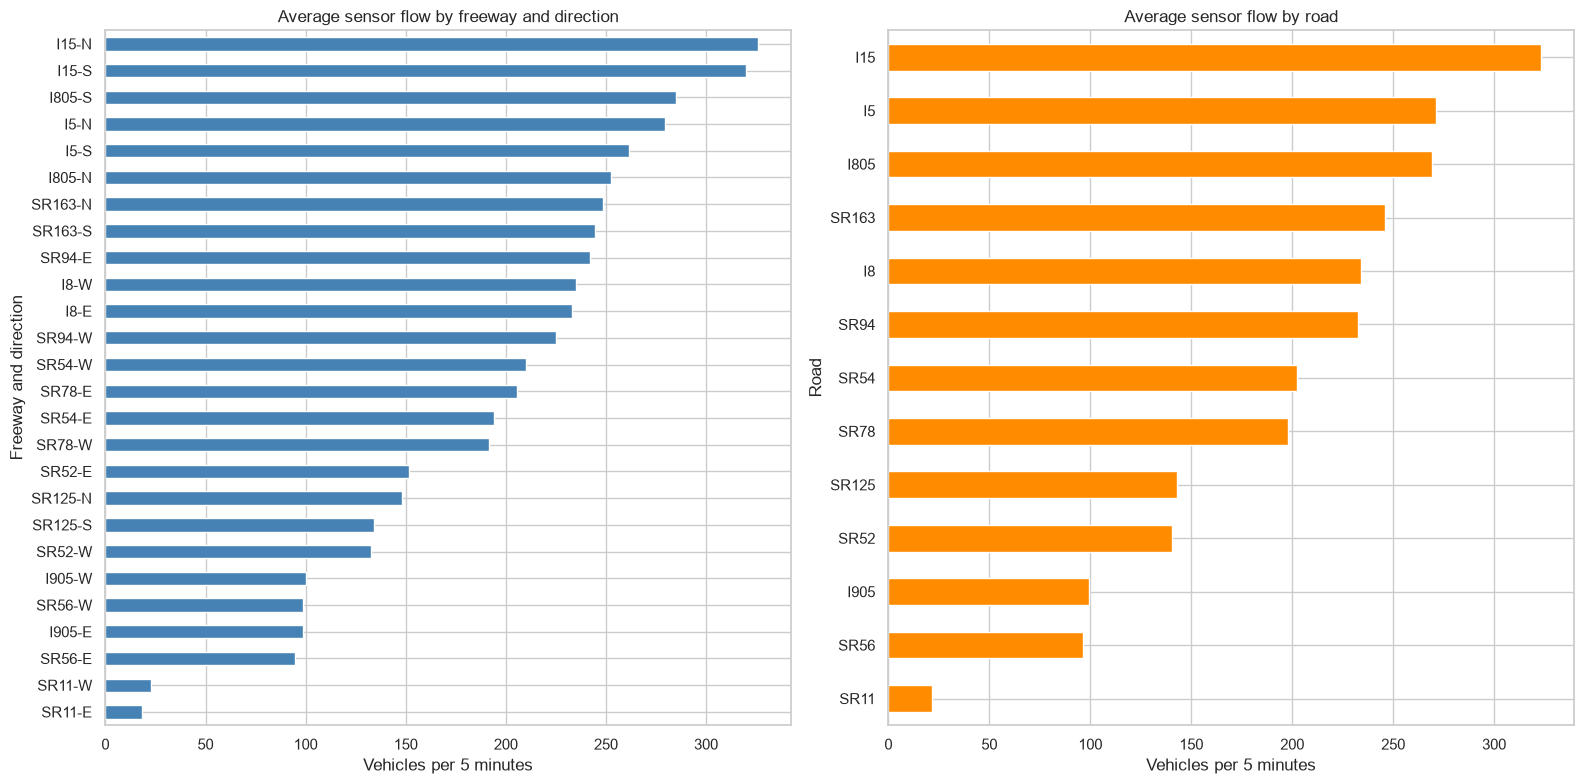

,average_sensor_flow,median_sensor_flow,sensors
Road,,,
I15,323.39,334.72,127
I5,270.98,280.12,181
I805,269.30,281.30,100
SR163,246.16,252.03,25
I8,234.07,230.18,86
SR94,232.68,238.18,36
SR54,202.17,203.25,6
SR78,197.72,192.96,44
SR125,143.07,151.39,30


In [16]:
fwy_summary = sensor_analysis.groupby("Fwy").agg(
    average_sensor_flow=("mean", "mean"),
    median_sensor_flow=("mean", "median"),
    sensors=("mean", "size"),
).sort_values("average_sensor_flow")

sensor_analysis["Road"] = sensor_analysis["Fwy"].str.rsplit("-", n=1).str[0]
road_summary = sensor_analysis.groupby("Road").agg(
    average_sensor_flow=("mean", "mean"),
    median_sensor_flow=("mean", "median"),
    sensors=("mean", "size"),
).sort_values("average_sensor_flow")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fwy_summary["average_sensor_flow"].plot.barh(ax=axes[0], color="steelblue")
axes[0].set(
    title="Average sensor flow by freeway and direction",
    xlabel="Vehicles per 5 minutes",
    ylabel="Freeway and direction",
)

road_summary["average_sensor_flow"].plot.barh(ax=axes[1], color="darkorange")
axes[1].set(
    title="Average sensor flow by road",
    xlabel="Vehicles per 5 minutes",
    ylabel="Road",
)
plt.tight_layout()
plt.show()

display(road_summary.sort_values("average_sensor_flow", ascending=False).round(2))

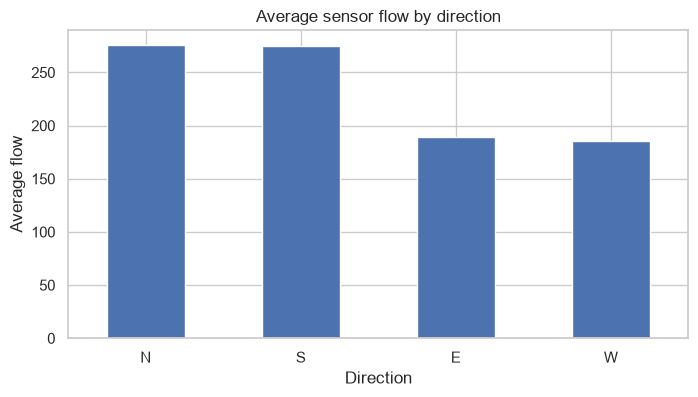

In [7]:
# Build a compact direction-level time series for later seasonal plots.
direction_flow = {}
for direction, group in metadata.groupby("Direction"):
    sensor_ids = [sensor_id for sensor_id in group["ID"] if sensor_id in traffic.columns]
    if sensor_ids:
        direction_flow[direction] = traffic[sensor_ids].mean(axis=1)
direction_flow = pd.DataFrame(direction_flow)

direction_summary["average_flow"].plot.bar(figsize=(8, 4), ylabel="Average flow", rot=0)
plt.title("Average sensor flow by direction")
plt.show()

## 5. Seasonal patterns

The network-level series averages all available sensors at each timestamp. This gives an interpretable overview without flattening the complete dataset.

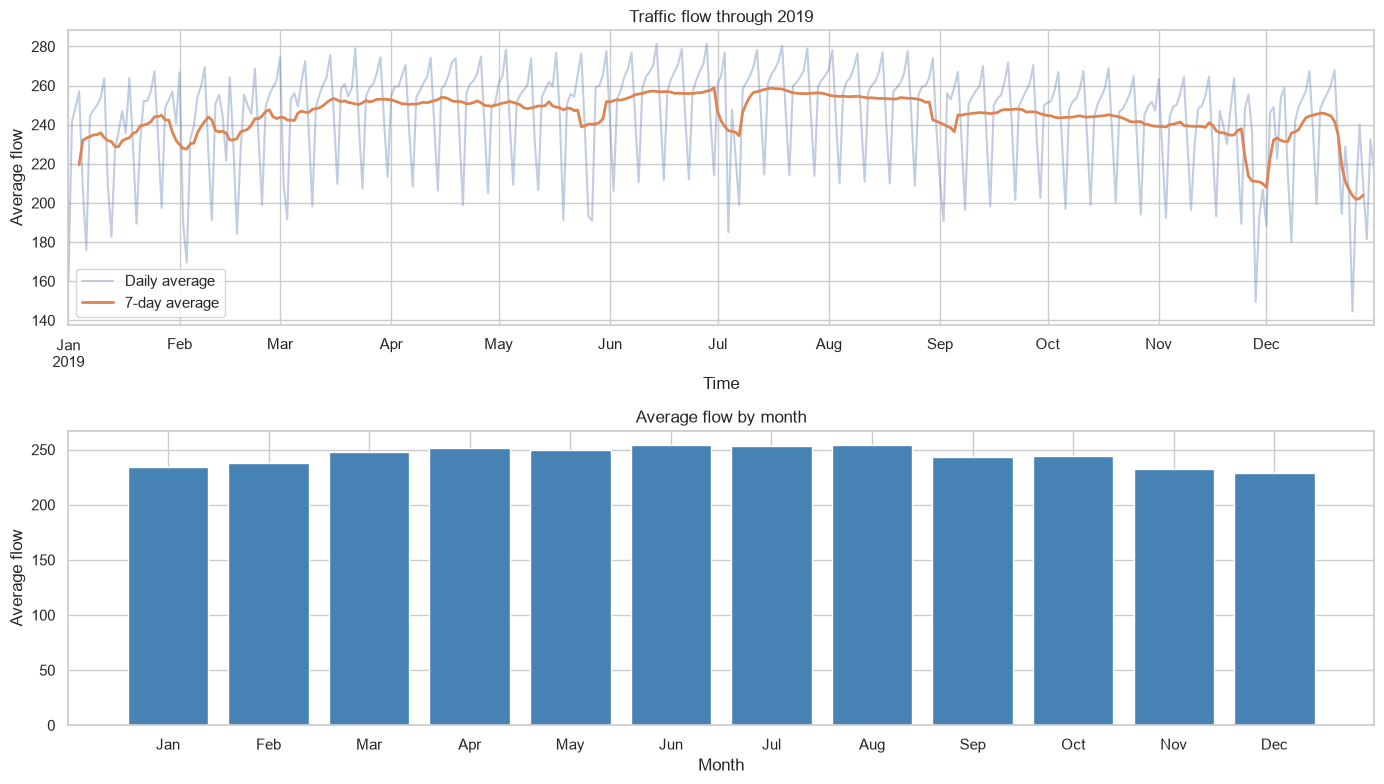

,average_flow
Time,
January,234.25
February,237.61
March,248.14
April,251.47
May,249.23
June,253.73
July,252.95
August,254.22
September,243.28


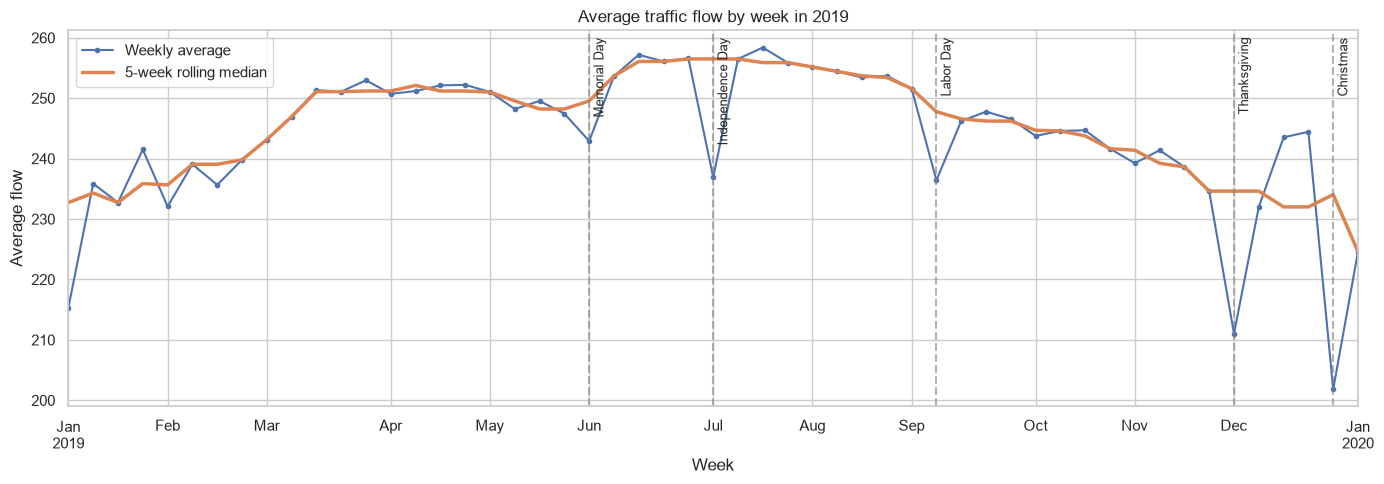

,average_flow,difference_from_5_week_median_%
Time,,
2019-12-29,201.83,-13.77
2019-12-01,211.04,-10.05
2019-07-07,236.93,-7.63
2019-01-06,215.35,-7.47
2019-09-08,236.41,-4.58
2019-06-02,242.91,-2.66
2019-02-03,232.08,-1.51
2019-02-17,235.65,-1.43
2019-12-08,232.01,-1.11


In [15]:
network_flow = traffic.mean(axis=1).rename("average_flow")
daily_flow = network_flow.resample("D").mean()
monthly_flow = network_flow.resample("MS").mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
daily_flow.plot(ax=axes[0], alpha=0.35, label="Daily average")
daily_flow.rolling(7, center=True).mean().plot(ax=axes[0], linewidth=2, label="7-day average")
axes[0].set(title="Traffic flow through 2019", ylabel="Average flow")
axes[0].legend()

month_labels = monthly_flow.index.strftime("%b")
axes[1].bar(month_labels, monthly_flow.values, color="steelblue")
axes[1].set(title="Average flow by month", xlabel="Month", ylabel="Average flow")
plt.tight_layout()
plt.show()

display(monthly_flow.rename(index=lambda date: date.strftime("%B")).round(2).to_frame())

# Weekly averages make short holiday-related or anomalous drops easier to see.
# W-SUN represents Monday-to-Sunday calendar weeks, labelled by Sunday.
weekly_flow = network_flow.resample("W-SUN").mean()
weekly_reference = weekly_flow.rolling(5, center=True, min_periods=3).median()

fig, ax = plt.subplots(figsize=(14, 5))
weekly_flow.plot(ax=ax, marker="o", markersize=3, linewidth=1.5, label="Weekly average")
weekly_reference.plot(ax=ax, linewidth=2.5, label="5-week rolling median")

reference_dates = {
    "Memorial Day": "2019-05-27",
    "Independence Day": "2019-07-04",
    "Labor Day": "2019-09-02",
    "Thanksgiving": "2019-11-28",
    "Christmas": "2019-12-25",
}
for label, date in reference_dates.items():
    ax.axvline(pd.Timestamp(date), color="gray", linestyle="--", alpha=0.6)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), ax.get_ylim()[1]),
        xytext=(3, -5),
        textcoords="offset points",
        rotation=90,
        va="top",
        fontsize=9,
    )

ax.set(title="Average traffic flow by week in 2019", xlabel="Week", ylabel="Average flow")
ax.legend()
plt.tight_layout()
plt.show()

weekly_deviation = (weekly_flow / weekly_reference - 1).mul(100)
lowest_weeks = pd.DataFrame({
    "average_flow": weekly_flow,
    "difference_from_5_week_median_%": weekly_deviation,
}).nsmallest(10, "difference_from_5_week_median_%")
display(lowest_weeks.round(2))

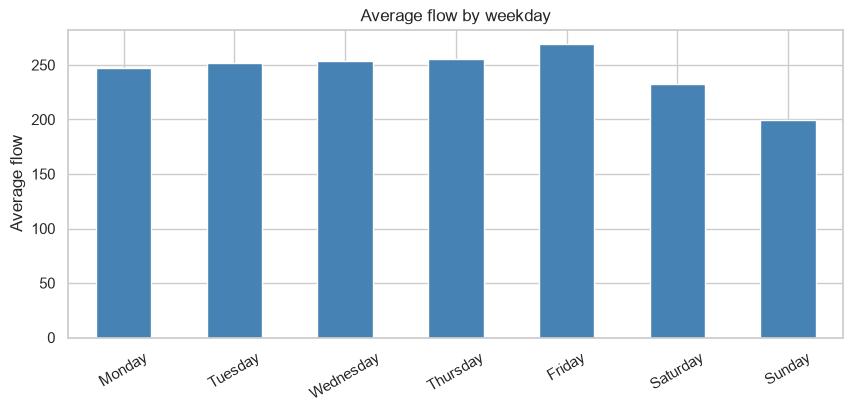

,average_flow
Monday,246.82
Tuesday,251.77
Wednesday,253.96
Thursday,255.29
Friday,269.05
Saturday,232.90
Sunday,199.57


In [9]:
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_flow = network_flow.groupby(network_flow.index.dayofweek).mean()
weekday_flow.index = weekday_names

weekday_flow.plot.bar(figsize=(10, 4), color="steelblue", rot=30)
plt.title("Average flow by weekday")
plt.ylabel("Average flow")
plt.show()
display(weekday_flow.round(2).to_frame())

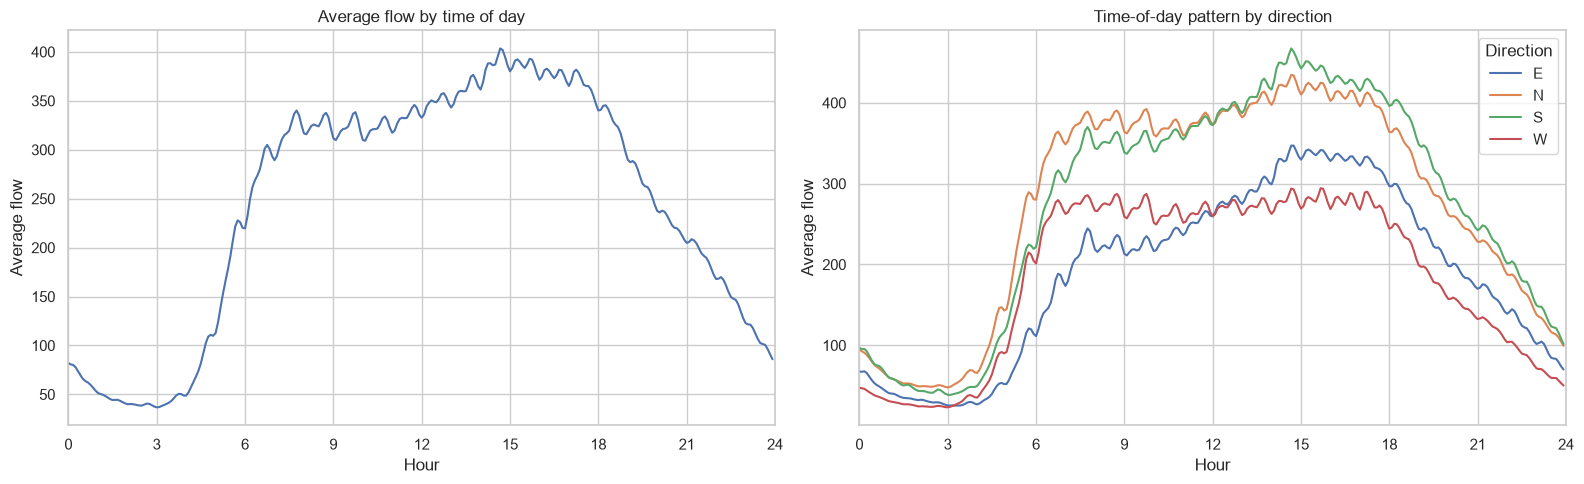

In [10]:
minute_of_day = network_flow.index.hour * 60 + network_flow.index.minute
time_of_day_flow = network_flow.groupby(minute_of_day).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(time_of_day_flow.index / 60, time_of_day_flow.values)
axes[0].set(
    title="Average flow by time of day", xlabel="Hour", ylabel="Average flow",
    xticks=range(0, 25, 3), xlim=(0, 24),
)

direction_time = direction_flow.groupby(
    direction_flow.index.hour * 60 + direction_flow.index.minute
).mean()
for direction in direction_time.columns:
    axes[1].plot(direction_time.index / 60, direction_time[direction], label=direction)
axes[1].set(
    title="Time-of-day pattern by direction", xlabel="Hour", ylabel="Average flow",
    xticks=range(0, 25, 3), xlim=(0, 24),
)
axes[1].legend(title="Direction")
plt.tight_layout()
plt.show()

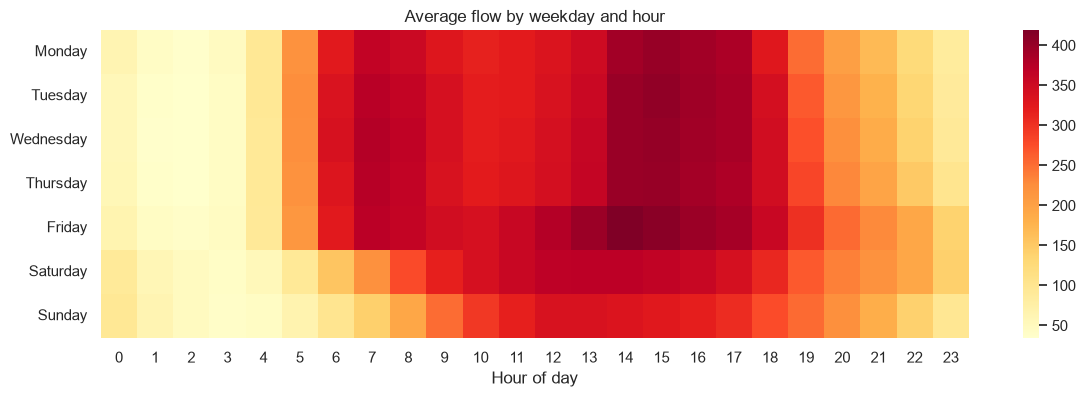

In [11]:
# Weekday × hour heatmap makes commuting peaks and weekend differences visible.
calendar_data = pd.DataFrame({
    "average_flow": network_flow.to_numpy(),
    "weekday": pd.Categorical(
        [weekday_names[value] for value in network_flow.index.dayofweek],
        categories=weekday_names,
        ordered=True,
    ),
    "hour": network_flow.index.hour,
})
weekday_hour = calendar_data.pivot_table(
    index="weekday", columns="hour", values="average_flow", aggfunc="mean", observed=True
)

plt.figure(figsize=(14, 4))
sns.heatmap(weekday_hour, cmap="YlOrRd")
plt.title("Average flow by weekday and hour")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.show()

## 6. Temporal dependence for forecasting

High correlation with recent, daily, or weekly history indicates which look-back periods should be useful model inputs.

,autocorrelation
one interval,0.999
one hour,0.939
one day,0.927
one week,0.979


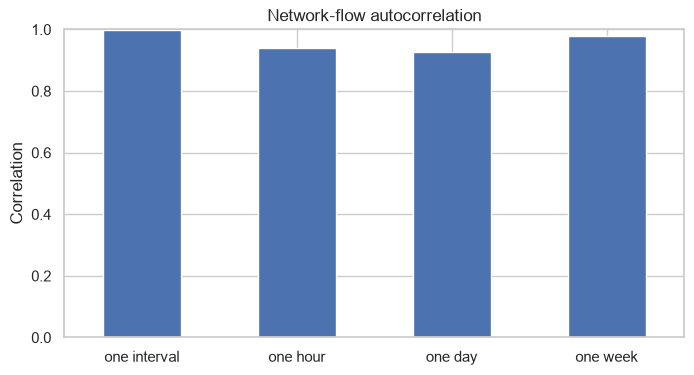

In [12]:
median_interval = traffic.index.to_series().diff().median()
forecast_lags = {
    "one interval": 1,
    "one hour": max(1, round(pd.Timedelta(hours=1) / median_interval)),
    "one day": max(1, round(pd.Timedelta(days=1) / median_interval)),
    "one week": max(1, round(pd.Timedelta(weeks=1) / median_interval)),
}
autocorrelation = pd.Series({
    name: network_flow.autocorr(lag=lag) for name, lag in forecast_lags.items()
}, name="autocorrelation")
display(autocorrelation.to_frame().round(3))

autocorrelation.plot.bar(figsize=(8, 4), ylim=(0, 1), rot=0)
plt.title("Network-flow autocorrelation")
plt.ylabel("Correlation")
plt.show()

### Normalize by lane count


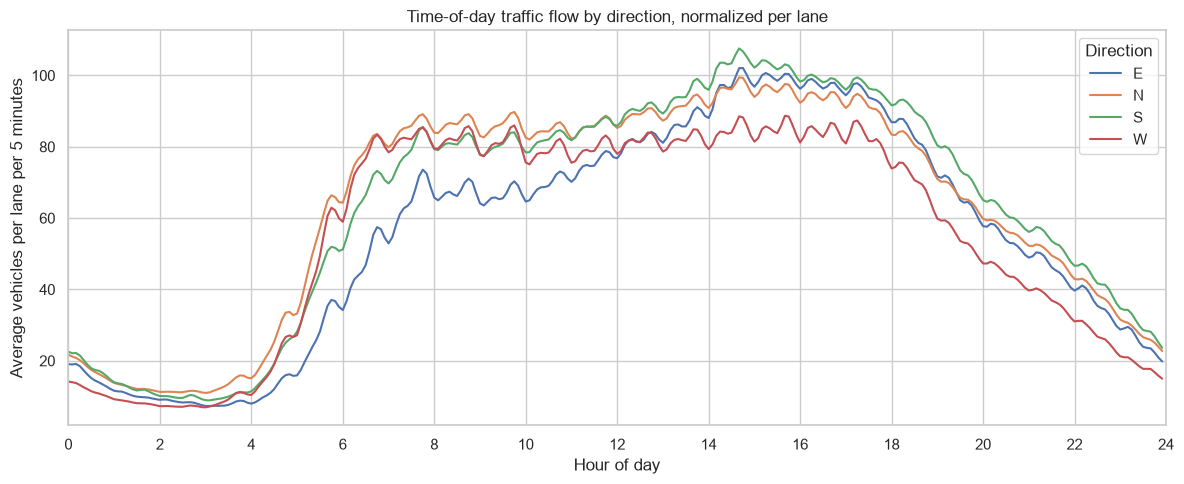

In [13]:
lanes_by_sensor = (
    metadata.set_index("ID")["Lanes"]
    .reindex(traffic.columns)
)

# Divide each sensor's total flow by its number of lanes.
flow_per_lane = traffic.div(lanes_by_sensor, axis="columns")

direction_flow_per_lane = {}

for direction, group in metadata.groupby("Direction"):
    sensor_ids = [
        sensor_id
        for sensor_id in group["ID"]
        if sensor_id in flow_per_lane.columns
    ]

    direction_flow_per_lane[direction] = (
        flow_per_lane[sensor_ids].mean(axis=1)
    )

direction_flow_per_lane = pd.DataFrame(direction_flow_per_lane)

minute_of_day = (
    direction_flow_per_lane.index.hour * 60
    + direction_flow_per_lane.index.minute
)
direction_pattern_per_lane = direction_flow_per_lane.groupby(minute_of_day).mean()

plt.figure(figsize=(12, 5))

for direction in direction_pattern_per_lane.columns:
    plt.plot(
        direction_pattern_per_lane.index / 60,
        direction_pattern_per_lane[direction],
        label=direction,
    )

plt.title("Time-of-day traffic flow by direction, normalized per lane")
plt.xlabel("Hour of day")
plt.ylabel("Average vehicles per lane per 5 minutes")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend(title="Direction")
plt.tight_layout()
plt.show()